# H4 — node2vec embeddings for the amino-acid similarity graphs

## Purpose
Turns the graphs built in [`network_generation.ipynb`](./network_generation.ipynb) into fixed-length node embeddings using **node2vec**, the same recipe as `h1_biological_overlap`/`h3_structural_similarity`.

Three graphs are loaded: two per-population graphs (`adverse_amino_acid.graphml`, `non_interacting_amino_acid.graphml`), kept to diagnose each population's topology and embedding quality in isolation, and one **combined** graph (`combined_amino_acid.graphml`, built in `network_generation.ipynb` from the union of both populations) -- the combined-graph embedding is the canonical artifact any downstream classifier should use.

## Pipeline
1. Load `adverse_amino_acid.graphml` / `non_interacting_amino_acid.graphml` / `combined_amino_acid.graphml`.
2. Set node2vec hyperparameters (same defaults as H1/H3, for comparability).
3. Run node2vec on each of the two per-population graphs.
4. Sanity-check the embeddings (shape, a PCA scatter, nearest-neighbor spot check).
5. Save the two per-population embeddings to `embeddings/{dataset}_amino_acid_node2vec.parquet`.
6. Quick analysis of embedding quality (edge-vs-random AUROC) for the two per-population graphs.
7. Run node2vec on the combined graph and save the canonical embedding for downstream modeling.
8. Sanity-check the combined embedding with the same checks as Sections 4/6.

See [`h3_structural_similarity/node2vec_embedding.ipynb`](../h3_structural_similarity/node2vec_embedding.ipynb) for the full node2vec/pecanpy glossary and background -- not repeated here to avoid duplication.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from node2vec_utils import run_node2vec, save_embeddings

H4_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim")
NETWORK_DIR = H4_DIR / "networks"
EMBEDDING_DIR = H4_DIR / "embeddings"
EMBEDDING_DIR.mkdir(exist_ok=True)


## 1. Load the graphs


In [2]:
DATASETS = ["adverse", "non_interacting"]
LAYER = "amino_acid"

graphs = {}
for dataset in DATASETS:
    G = nx.read_graphml(NETWORK_DIR / f"{dataset}_{LAYER}.graphml")
    graphs[dataset] = G
    print(f"{dataset:<16}: {G.number_of_nodes():>5} nodes, {G.number_of_edges():>7} edges")


adverse         :  1893 nodes,   20868 edges
non_interacting :  1900 nodes,   23315 edges


## 2. node2vec hyperparameters

Same paper-default settings (`p = q = 1`) as H1/H3, for comparability.


In [3]:
NODE2VEC_PARAMS = dict(
    dimensions=128,
    walk_length=80,
    num_walks=10,
    p=1.0,
    q=1.0,
    window=10,
    epochs=5,
    workers=1,
    seed=42,
)


## 3. Run node2vec

Simulates the random walks and trains the skip-gram model for each graph.


In [4]:
amino_acid_embeddings = {}
for dataset, G in graphs.items():
    print(f"Running node2vec on {dataset}...")
    amino_acid_embeddings[dataset] = run_node2vec(G, **NODE2VEC_PARAMS)
    print(f"  -> embeddings shape: {amino_acid_embeddings[dataset].shape}")


Running node2vec on adverse...
  -> embeddings shape: (1893, 128)
Running node2vec on non_interacting...
  -> embeddings shape: (1900, 128)


## 4. Sanity checks

Every node in the graph should get an embedding row, a 2D PCA projection shouldn't collapse to a point, and a random drug's nearest embedding neighbors should look at least plausible.


adverse         : 0 node(s) missing an embedding (isolates can't be walked -- expect isolate_count from network_generation.ipynb)
non_interacting : 0 node(s) missing an embedding (isolates can't be walked -- expect isolate_count from network_generation.ipynb)


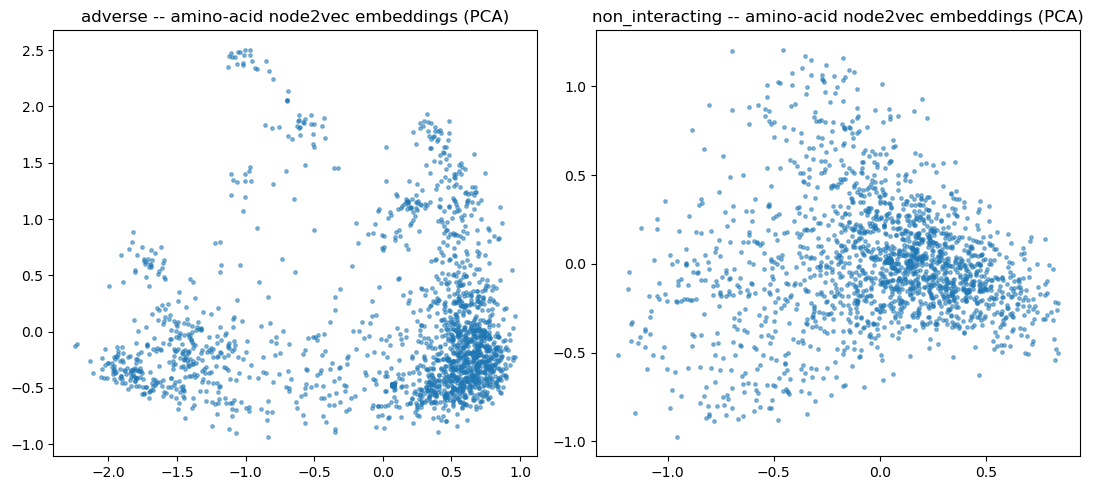

In [5]:
for dataset, G in graphs.items():
    n_missing = G.number_of_nodes() - amino_acid_embeddings[dataset].shape[0]
    print(f"{dataset:<16}: {n_missing} node(s) missing an embedding (isolates can't be walked -- expect isolate_count from network_generation.ipynb)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (dataset, emb) in zip(axes, amino_acid_embeddings.items()):
    coords = PCA(n_components=2, random_state=42).fit_transform(emb.values)
    ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
    ax.set_title(f"{dataset} -- amino-acid node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()


In [6]:
dataset_to_check = "adverse"
G = graphs[dataset_to_check]
emb = amino_acid_embeddings[dataset_to_check]

sample_node = max(G.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(emb.loc[[sample_node]], emb).flatten()
nearest = pd.Series(sims, index=emb.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G.nodes[sample_node].get("name", sample_node)
print(f"Nearest embedding neighbors of {sample_node} ({sample_name}):")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G.has_edge(sample_node, neighbor_id)
    neighbor_name = G.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")


Nearest embedding neighbors of DB09085 (Tetracaine):
  DB12459 (Belotecan): cosine_sim=0.698, direct graph edge=True
  DB07232 (Veliparib): cosine_sim=0.671, direct graph edge=True
  DB00027 (Gramicidin D): cosine_sim=0.662, direct graph edge=True
  DB00645 (Dyclonine): cosine_sim=0.649, direct graph edge=True
  DB00948 (Mezlocillin): cosine_sim=0.644, direct graph edge=True


## 5. Save embeddings

Each embedding table is written to `embeddings/{dataset}_amino_acid_node2vec.parquet`, indexed by `drug_id`.


In [7]:
for dataset, emb in amino_acid_embeddings.items():
    out_path = EMBEDDING_DIR / f"{dataset}_amino_acid_node2vec.parquet"
    save_embeddings(emb, out_path)
    print(f"Saved {emb.shape} embedding table to {out_path}")


Saved (1893, 128) embedding table to C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim\embeddings\adverse_amino_acid_node2vec.parquet
Saved (1900, 128) embedding table to C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim\embeddings\non_interacting_amino_acid_node2vec.parquet


## 6. Quick analysis: did node2vec actually learn the graph structure?

For each graph, compare embedding cosine similarity of real edges against random (mostly unconnected) drug pairs, summarized with an AUROC -- a check on the *embedding step itself*, not a claim about DDI predictiveness.


In [8]:
rng = np.random.default_rng(42)
analysis_rows = []
similarity_samples = {}

for dataset, G in graphs.items():
    emb = amino_acid_embeddings[dataset]
    node_ids = list(emb.index)
    id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    normed = emb.values / np.linalg.norm(emb.values, axis=1, keepdims=True)

    edges = [(u, v) for u, v in G.edges() if u in id_to_idx and v in id_to_idx]
    pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

    n_nodes = len(node_ids)
    neg_sims = []
    while len(neg_sims) < len(edges):
        i, j = rng.integers(0, n_nodes, size=2)
        if i == j:
            continue
        u, v = node_ids[i], node_ids[j]
        if G.has_edge(u, v):
            continue
        neg_sims.append(normed[i] @ normed[j])
    neg_sims = np.array(neg_sims)

    y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
    y_score = np.concatenate([pos_sims, neg_sims])

    similarity_samples[dataset] = (pos_sims, neg_sims)
    analysis_rows.append({
        "dataset": dataset,
        "n_nodes": n_nodes,
        "n_edges": len(edges),
        "mean_cos_sim_edges": pos_sims.mean(),
        "mean_cos_sim_random_pairs": neg_sims.mean(),
        "auroc_edge_vs_random": roc_auc_score(y_true, y_score),
    })

embedding_quality_df = pd.DataFrame(analysis_rows)
embedding_quality_df


,dataset,n_nodes,n_edges,mean_cos_sim_edges,mean_cos_sim_random_pairs,auroc_edge_vs_random
0,adverse,1893,20868,0.613023,0.198785,0.963211
1,non_interacting,1900,23315,0.345822,0.103290,0.979276


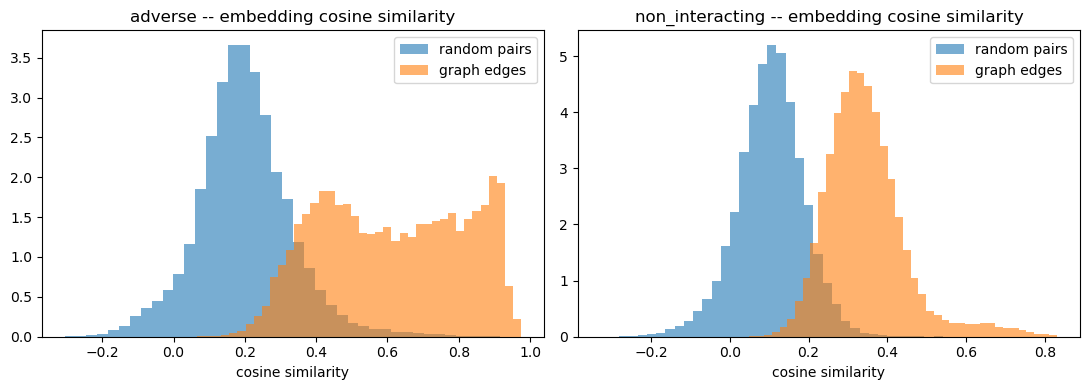

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dataset in zip(axes, graphs):
    pos_sims, neg_sims = similarity_samples[dataset]
    ax.hist(neg_sims, bins=40, alpha=0.6, density=True, label="random pairs")
    ax.hist(pos_sims, bins=40, alpha=0.6, density=True, label="graph edges")
    ax.set_title(f"{dataset} -- embedding cosine similarity")
    ax.set_xlabel("cosine similarity")
    ax.legend()
plt.tight_layout()
plt.show()


## 7. Load the combined graph and train the canonical embedding (for downstream modeling)

Same reasoning as `h3_structural_similarity`'s Section 7: the two per-population embeddings above come from two separately-trained node2vec models with no shared coordinate system, so neither is safe to feed a downstream classifier. `network_generation.ipynb` already built `combined_amino_acid.graphml` from the union of both pair populations with label-agnostic edge weights -- we just load it here, train node2vec on it once, and save that as the single embedding table any downstream classifier notebook should use.


In [10]:
G_combined = nx.read_graphml(NETWORK_DIR / "combined_amino_acid.graphml")

n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
print(f"Combined graph: {G_combined.number_of_nodes():,} nodes, {G_combined.number_of_edges():,} edges, "
      f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")


Combined graph: 1,900 nodes, 21,367 edges, 105 isolate(s), density=0.01184


In [11]:
combined_embeddings = run_node2vec(G_combined, **NODE2VEC_PARAMS)
print(f"Combined embeddings shape: {combined_embeddings.shape}")

save_embeddings(combined_embeddings, EMBEDDING_DIR / "combined_amino_acid_node2vec.parquet")
print(f"Saved to {EMBEDDING_DIR / 'combined_amino_acid_node2vec.parquet'} -- use this file for any downstream classifier.")


Combined embeddings shape: (1900, 128)
Saved to C:\Users\ashto\ddi-prediction\notebooks\h4_target_amino_acid_sim\embeddings\combined_amino_acid_node2vec.parquet -- use this file for any downstream classifier.


## 8. Sanity-check the combined embedding

Same checks as Sections 4 and 6, run against `G_combined`/`combined_embeddings` -- this is the artifact downstream classifiers actually consume.


combined        : 0 node(s) missing an embedding (isolates)


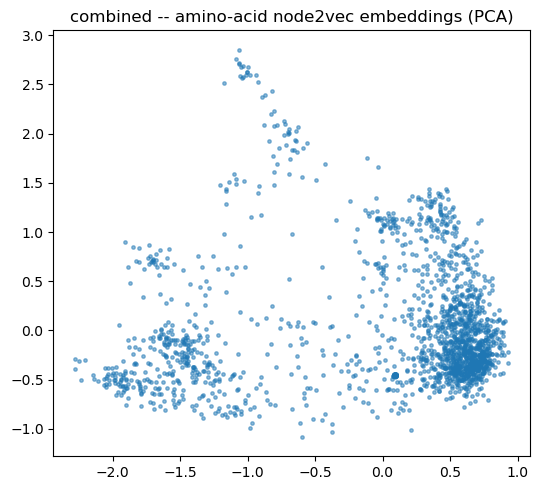


Nearest embedding neighbors of DB09085 (Tetracaine):
  DB01066 (Cefditoren): cosine_sim=0.559, direct graph edge=True
  DB14733 (Ceftobiprole medocaril): cosine_sim=0.556, direct graph edge=True
  DB01563 (Chloral hydrate): cosine_sim=0.550, direct graph edge=True
  DB01603 (Meticillin): cosine_sim=0.547, direct graph edge=True
  DB00833 (Cefaclor): cosine_sim=0.546, direct graph edge=True

combined        : mean_cos_sim_edges=0.576, mean_cos_sim_random_pairs=0.190, auroc_edge_vs_random=0.947


In [12]:
n_missing = G_combined.number_of_nodes() - combined_embeddings.shape[0]
print(f"combined        : {n_missing} node(s) missing an embedding (isolates)")

fig, ax = plt.subplots(figsize=(5.5, 5))
coords = PCA(n_components=2, random_state=42).fit_transform(combined_embeddings.values)
ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.5)
ax.set_title("combined -- amino-acid node2vec embeddings (PCA)")
plt.tight_layout()
plt.show()

sample_node = max(G_combined.degree, key=lambda x: x[1])[0]  # pick a well-connected node so its neighbors are informative
sims = cosine_similarity(combined_embeddings.loc[[sample_node]], combined_embeddings).flatten()
nearest = pd.Series(sims, index=combined_embeddings.index).drop(sample_node).sort_values(ascending=False).head(5)

sample_name = G_combined.nodes[sample_node].get("name", sample_node)
print(f"\nNearest embedding neighbors of {sample_node} ({sample_name}):")
for neighbor_id, sim in nearest.items():
    is_graph_neighbor = G_combined.has_edge(sample_node, neighbor_id)
    neighbor_name = G_combined.nodes[neighbor_id].get("name", neighbor_id)
    print(f"  {neighbor_id} ({neighbor_name}): cosine_sim={sim:.3f}, direct graph edge={is_graph_neighbor}")

# edge-vs-random AUROC, same recipe as Section 6, scored against the combined graph's own edges
node_ids = list(combined_embeddings.index)
id_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
normed = combined_embeddings.values / np.linalg.norm(combined_embeddings.values, axis=1, keepdims=True)

edges = [(u, v) for u, v in G_combined.edges() if u in id_to_idx and v in id_to_idx]
pos_sims = np.array([normed[id_to_idx[u]] @ normed[id_to_idx[v]] for u, v in edges])

n_nodes = len(node_ids)
neg_sims = []
while len(neg_sims) < len(edges):
    i, j = rng.integers(0, n_nodes, size=2)
    if i == j:
        continue
    u, v = node_ids[i], node_ids[j]
    if G_combined.has_edge(u, v):
        continue
    neg_sims.append(normed[i] @ normed[j])
neg_sims = np.array(neg_sims)

y_true = np.concatenate([np.ones(len(pos_sims)), np.zeros(len(neg_sims))])
y_score = np.concatenate([pos_sims, neg_sims])

print(f"\ncombined        : mean_cos_sim_edges={pos_sims.mean():.3f}, "
      f"mean_cos_sim_random_pairs={neg_sims.mean():.3f}, "
      f"auroc_edge_vs_random={roc_auc_score(y_true, y_score):.3f}")


## Conclusions & recommendations (from the executed run)

### Conclusions

1. **node2vec clearly learned the graph structure, for both datasets and the combined graph.** `auroc_edge_vs_random` is **0.963** (adverse), **0.979** (non_interacting), and **0.947** (combined) -- embedding cosine similarity strongly separates real amino-acid-similarity edges from random drug pairs, confirming the walk simulation + skip-gram training captured each graph's neighborhood structure.
2. **Every node received an embedding, including the ~105-106 isolates per graph** (`n_missing = 0` throughout) -- pecanpy assigns isolated nodes a valid (if less meaningful) vector rather than dropping them, so no pair needs to be excluded downstream for a missing embedding.
3. **Absolute cosine similarities differ noticeably between populations**: adverse edges average 0.613 vs. 0.199 for random pairs, while non_interacting edges average only 0.346 vs. 0.103 -- the non_interacting graph is a bit sparser in embedding space even though its AUROC separation is (slightly) stronger. This mirrors the H3 pattern where AUROC (relative ranking) and absolute similarity scale are independent signals.
4. **This is a structural sanity check on the embedding step, not a DDI-predictiveness claim** -- it confirms the embeddings faithfully encode *this graph's* edges (which were themselves built from the `kmer_cosine_best_match_avg` amino-acid similarity kernel), not that amino-acid similarity itself is the best predictor of adverse DDIs. That comparison belongs in a future `amino_acid_sim_embedding_comparison.ipynb`, following the same three-model (raw score / node2vec / raw kernel features) methodology as `h3_structural_similarity`.

### Recommendations

1. **For any downstream classifier, use `embeddings/combined_amino_acid_node2vec.parquet` (Section 7)** -- not the two per-population tables, which would leak the label the same way explained in Section 7's markdown.
2. Both datasets embed well here, so there's no immediate need to retune `NODE2VEC_PARAMS` per-dataset for this hypothesis.
3. Re-run Section 6/8's checks after any future re-tuning of `network_generation.ipynb`'s sparsification settings, or after switching `similarity_score` to a different aggregation metric (e.g. `max_similarity`, per `amino_acid_sim_notebook.ipynb`'s recommendation to revisit it).
4. Next step: build `amino_acid_sim_embedding_comparison.ipynb` (raw `similarity_score` vs. these node2vec embeddings vs. a raw per-drug k-mer feature vector) to see whether amino-acid similarity is predictive of adverse DDI status at all, following H3's three-model comparison recipe.
